# US Data Centers — Geospatial Data Analysis

## Pipeline Data Analyst

### Problématique métier

+ **Où sont concentrés les data centers aux États-Unis et quels États concentrent le plus de sites observés ?**

+ Pipeline : **collecte → nettoyage → KPI → GeoPandas → Contextily → Plotly → conclusions**.

> Le dataset décrit les records présents dans la source publique. Il ne constitue pas un recensement exhaustif de tous les data centers américains.

In [1]:
# Installation (une seule fois si nécessaire)
# !pip install pandas numpy geopandas matplotlib contextily plotly requests pyogrio jupyter

In [4]:
import re
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import plotly.express as px

warnings.filterwarnings("ignore")

## 1. Récupération automatique du dataset réel

Source publique : PNNL IM3 Open Source Data Center Atlas, distribué via Energy Factbook.

In [3]:
import io
import requests
import pandas as pd

DATA_URL = "https://energyfactbook.com/data-centers/data/pnnl_atlas_records.csv"

# we use a User-Agent similar to that of a browser when reading the CSV 
response = requests.get(
    DATA_URL,
    headers={
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 Chrome/131.0 Safari/537.36"
        )
    },
    timeout=30,
)

response.raise_for_status()

# We can now build our DataFrame using Pandas as pd
df_raw = pd.read_csv(io.BytesIO(response.content))

print("Lignes :", len(df_raw))
print("Colonnes :", len(df_raw.columns))
display(df_raw.head())
print(df_raw.columns.tolist())

Lignes : 1237
Colonnes : 10


,id,layer,state,state_abb,county,operator,name,sqft,lat,lon
0,2744301,building,New Jersey,NJ,Middlesex County,NaN,Verizon,105786,40.54426,-74.49652
1,14930068,building,New Mexico,NM,Bernalillo County,Sandia National Laboratories,HPC,158463,35.04994,-106.54282
2,15884451,building,New Jersey,NJ,Union County,Barclays,Barclays Datacenter,94373,40.64375,-74.28548
3,16282459,building,Maryland,MD,Anne Arundel County,AiNET,CyberNAP Glen Burnie,89879,39.14024,-76.60643
4,19390019,building,North Dakota,ND,Cass County,NaN,Dakota Carrier Network,25931,46.81510,-96.84433


['id', 'layer', 'state', 'state_abb', 'county', 'operator', 'name', 'sqft', 'lat', 'lon']


In [ ]:
# This block code return 
# an error as "HTTPError: HTTP Error 403: Forbidden"
# The server is rejecting pandas request. 
# The code block above replaces the commented-out code below 
# we send a User-Agent similar to that of a browser when reading the CSV data. We can then build our DataFrame using Pandas.

# DATA_URL = "https://energyfactbook.com/data-centers/data/pnnl_atlas_records.csv"
# 
# df_raw = pd.read_csv(DATA_URL)
# 
# print("Lignes :", len(df_raw))
# print("Colonnes :", len(df_raw.columns))
# display(df_raw.head())
# print(df_raw.columns.tolist())

In [5]:
# Normalisation des noms de colonnes avec une RegEx
df = df_raw.copy()
df.columns = (
    df.columns.str.strip().str.lower()
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)
print(df.columns.tolist())

['id', 'layer', 'state', 'state_abb', 'county', 'operator', 'name', 'sqft', 'lat', 'lon']


## 2. Contrôle qualité et nettoyage

On vérifie les doublons, les valeurs manquantes et les coordonnées. Le parsing des coordonnées est conçu pour fonctionner avec une colonne `coordinates` de type `(latitude, longitude)` ou avec des colonnes latitude/longitude déjà séparées.

In [6]:
print("Doublons exacts :", df.duplicated().sum())
display(df.isna().sum().sort_values(ascending=False).head(15))

def extract_coordinates(data):
    result = data.copy()

    lat_cols = [c for c in result.columns if c in ["latitude", "lat", "y"]]
    lon_cols = [c for c in result.columns if c in ["longitude", "lon", "lng", "x"]]

    if lat_cols and lon_cols:
        result["latitude"] = pd.to_numeric(result[lat_cols[0]], errors="coerce")
        result["longitude"] = pd.to_numeric(result[lon_cols[0]], errors="coerce")
        return result

    coord_cols = [c for c in result.columns if "coordinate" in c or c == "coords"]
    if not coord_cols:
        raise ValueError("Aucune colonne de coordonnées détectée. Inspectez df.columns.")

    coord_col = coord_cols[0]

    def parse(value):
        if pd.isna(value):
            return pd.Series([np.nan, np.nan])
        nums = re.findall(r"-?\d+(?:\.\d+)?", str(value))
        return pd.Series([float(nums[0]), float(nums[1])] if len(nums) >= 2 else [np.nan, np.nan])

    result[["latitude", "longitude"]] = result[coord_col].apply(parse)
    return result

df = extract_coordinates(df)
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

valid = df["latitude"].between(-90, 90) & df["longitude"].between(-180, 180)
print("Coordonnées valides :", valid.sum())
print("Coordonnées invalides :", (~valid).sum())

df = df.loc[valid].copy()

Doublons exacts : 0


operator     412
name         252
layer          0
id             0
state_abb      0
state          0
county         0
sqft           0
lat            0
lon            0
dtype: int64

Coordonnées valides : 1237
Coordonnées invalides : 0


In [7]:
# GeoDataFrame WGS84
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)
display(gdf.head(4))

,id,layer,state,state_abb,county,operator,name,sqft,lat,lon,latitude,longitude,geometry
0,2744301,building,New Jersey,NJ,Middlesex County,NaN,Verizon,105786,40.54426,-74.49652,40.54426,-74.49652,POINT (-74.49652 40.54426)
1,14930068,building,New Mexico,NM,Bernalillo County,Sandia National Laboratories,HPC,158463,35.04994,-106.54282,35.04994,-106.54282,POINT (-106.54282 35.04994)
2,15884451,building,New Jersey,NJ,Union County,Barclays,Barclays Datacenter,94373,40.64375,-74.28548,40.64375,-74.28548,POINT (-74.28548 40.64375)
3,16282459,building,Maryland,MD,Anne Arundel County,AiNET,CyberNAP Glen Burnie,89879,39.14024,-76.60643,39.14024,-76.60643,POINT (-76.60643 39.14024)


## 3. KPI géographiques

Le KPI principal est le nombre de records de data centers observés par État.

In [14]:
state_counts = (
    gdf.groupby("state")
       .size()
       .reset_index(name="data_center_count")
       .sort_values("data_center_count", ascending=False)
)

state_counts["share_pct"] = (
    state_counts["data_center_count"] / state_counts["data_center_count"].sum() * 100
)
state_counts["cumulative_pct"] = state_counts["share_pct"].cumsum() 
# `.cumsum()` method: return cumulative sum over a DataFrame or Series axis 
#     (first param.: axis, second param.: exclude NA/null value on True by default, optional third: ***args, kwargs)

display(state_counts.head(15))

,state,data_center_count,share_pct,cumulative_pct
40,Virginia,281,22.716249,22.716249
38,Texas,113,9.135004,31.851253
32,Oregon,100,8.084074,39.935327
3,California,97,7.841552,47.776880
30,Ohio,81,6.548100,54.324980
41,Washington,71,5.739693,60.064673
11,Iowa,58,4.688763,64.753436
25,New Jersey,46,3.718674,68.472110
9,Illinois,42,3.395311,71.867421
1,Arizona,42,3.395311,75.262732


### Remarque pour les prochaines étapes: 

- *On peut noter que des états au climat désertique (en stress hydrique tel certaines zone du Texas, et la totalité de l'Arizona et du Nevada) ont un taux élevé de Data Centers*. 
- *l'implentation des Data Center ne semble pas être influencé par les problèmes environnementaux que provoquent ou aggravent une forte consommation en eau dans des régions en situation de stress hydrique*.

- *It is worth noting that states facing water stress (such as Texas, Arizona, and Nevada) have a high concentration of data centers; the deployment of data centers does not appear to be influenced by the environmental problems caused or exacerbated by high water consumption in regions experiencing water stress*.

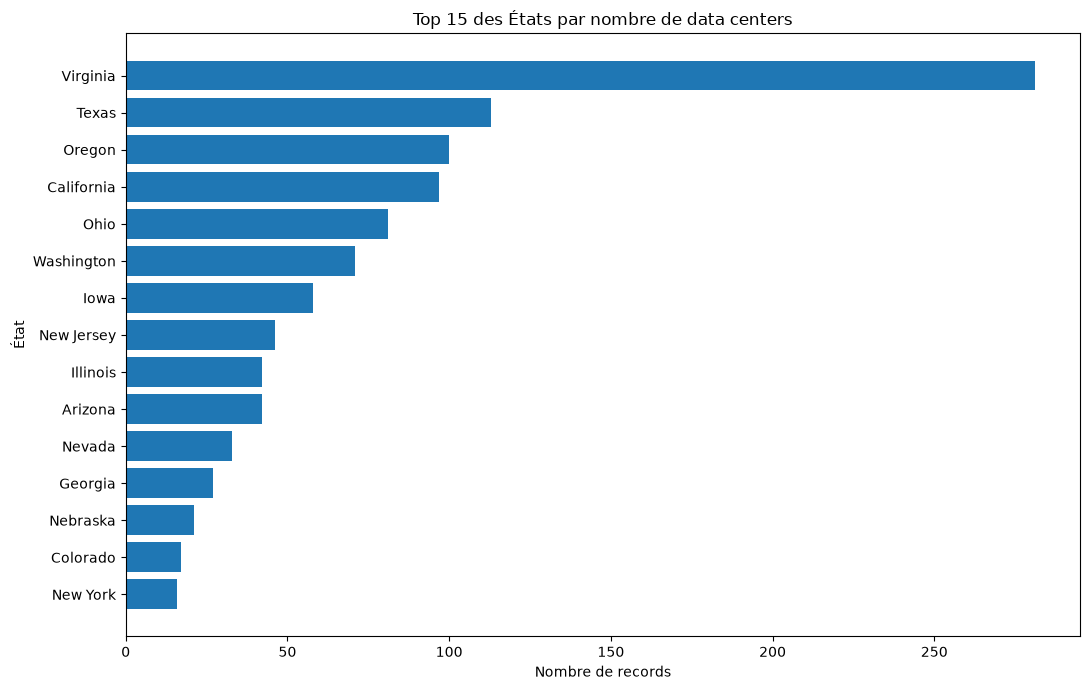

In [15]:
top15 = state_counts.head(15).sort_values("data_center_count")

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top15["state"], top15["data_center_count"])
ax.set_title("Top 15 des États par nombre de data centers")
ax.set_xlabel("Nombre de records")
ax.set_ylabel("État")
plt.tight_layout()
plt.show()

In [16]:
first_over_50 = state_counts[state_counts["cumulative_pct"] >= 50].head(1)
print("États nécessaires pour atteindre au moins 50 % :",
      len(state_counts[state_counts["cumulative_pct"] < 50]) + 1)
display(first_over_50)

États nécessaires pour atteindre au moins 50 % : 5


,state,data_center_count,share_pct,cumulative_pct
30,Ohio,81,6.5481,54.32498


## 4. Frontières des États — U.S. Census Bureau

In [17]:
STATES_URL = "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_state_500k.zip"
states = gpd.read_file(STATES_URL)

usps = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
    "Colorado":"CO","Connecticut":"CT","Delaware":"DE","Florida":"FL","Georgia":"GA",
    "Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA",
    "Kansas":"KS","Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD",
    "Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS",
    "Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV","New Hampshire":"NH",
    "New Jersey":"NJ","New Mexico":"NM","New York":"NY","North Carolina":"NC",
    "North Dakota":"ND","Ohio":"OH","Oklahoma":"OK","Oregon":"OR","Pennsylvania":"PA",
    "Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD","Tennessee":"TN",
    "Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA","Washington":"WA",
    "West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY","District of Columbia":"DC"
}

state_counts["STUSPS"] = state_counts["state"].map(usps)
states_map = states.merge(state_counts, on="STUSPS", how="left")
states_map["data_center_count"] = states_map["data_center_count"].fillna(0).astype(int)
states_map = states_map[~states_map["STUSPS"].isin(["PR","GU","VI","MP","AS"])].copy()

## 5. Carte choroplèthe GeoPandas / cartopy

In [32]:
!pip install cartopy

In [18]:
# ============================================================
# 5. CARTE CHOROPLÈTHE — GeoPandas + Cartopy
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ------------------------------------------------------------
# 5.1 Nombre de data centers par État
# ------------------------------------------------------------

state_counts = (
    df
    .dropna(subset=["state_abb"])
    .groupby("state_abb")
    .size()
    .reset_index(name="data_centers")
)

state_counts["share_pct"] = (
    state_counts["data_centers"]
    / state_counts["data_centers"].sum()
    * 100
)

state_counts["cumulative_pct"] = state_counts["share_pct"].cumsum()

print("Nombre d'États présents dans le dataset :",
      state_counts["state_abb"].nunique())

print("\nTop 10 des États :")

print(
    state_counts
    .sort_values(
        "data_centers",
        ascending=False
    )
    .head(10)
)

Nombre d'États présents dans le dataset : 44

Top 10 des États :
   state_abb  data_centers  share_pct  cumulative_pct
40        VA           281  22.716249       92.320129
38        TX           113   9.135004       68.552951
32        OR           100   8.084074       56.507680
3         CA            97   7.841552       12.045271
30        OH            81   6.548100       48.100243
41        WA            71   5.739693       98.059822
8         IA            58   4.688763       21.503638
26        NJ            46   3.718674       36.782538
10        IL            42   3.395311       25.222312
2         AZ            42   3.395311        4.203719


### 5.2 Téléchargement des frontières des États

In [2]:
# ------------------------------------------------------------
# 5.2 Frontières des États américains
# ------------------------------------------------------------

url_states = (
    "https://www2.census.gov/geo/tiger/GENZ2024/shp/"
    "cb_2024_us_state_500k.zip"
)

states = gpd.read_file(url_states)

print("CRS :", states.crs)
print("Nombre de territoires :", len(states))

CRS : EPSG:4269
Nombre de territoires : 56


In [9]:
# On conserve uniquement les 50 États américains :

us_states_fips = [
    "01", "02", "04", "05", "06", "08", "09", "10", "11",
    "12", "13", "16", "17", "18", "19", "20", "21", "22",
    "23", "24", "25", "26", "27", "28", "29", "30", "31",
    "32", "33", "34", "35", "36", "37", "38", "39", "40",
    "41", "42", "44", "45", "46", "47", "48", "49", "50",
    "51", "53", "54", "55", "56"
]

states = states[
    states["STATEFP"].isin(us_states_fips)
].copy()

display(states)

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,35,00897535,0400000US35,35,NM,New Mexico,00,314198519809,726531289,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
1,46,01785534,0400000US46,46,SD,South Dakota,00,196341670967,3387563375,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
2,06,01779778,0400000US06,06,CA,California,00,403673433805,20291632828,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."
3,21,01779786,0400000US21,21,KY,Kentucky,00,102266755818,2384136185,"MULTIPOLYGON (((-89.40565 36.52816, -89.39868 ..."
4,01,01779775,0400000US01,01,AL,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
5,13,01705317,0400000US13,13,GA,Georgia,00,149485762701,4419221858,"MULTIPOLYGON (((-81.27939 31.30792, -81.27716 ..."
6,05,00068085,0400000US05,05,AR,Arkansas,00,134658517854,3122715710,"POLYGON ((-94.61792 36.49941, -94.61765 36.499..."
7,42,01779798,0400000US42,42,PA,Pennsylvania,00,115881476238,3397613881,"POLYGON ((-80.51989 40.90666, -80.51963 40.911..."
8,29,01779791,0400000US29,29,MO,Missouri,00,178052403953,2487375487,"POLYGON ((-95.77355 40.5782, -95.76853 40.5833..."
9,08,01779779,0400000US08,08,CO,Colorado,00,268418973518,1185541418,"POLYGON ((-109.06025 38.59933, -109.05954 38.7..."


### 5.3 Jointure avec nos données

In [10]:
# ------------------------------------------------------------
# 5.3 Jointure
# ------------------------------------------------------------

states_map = states.merge(
    state_counts,
    left_on="STUSPS",
    right_on="state_abb",
    how="left"
)

# Les États sans data center observé = 0
states_map["data_centers"] = (
    states_map["data_centers"]
    .fillna(0)
    .astype(int)
)

In [ ]:
# Datas check  /  Vérification des données

states_map[
    ["NAME", "STUSPS", "data_centers"]
].sort_values(
    "data_centers",
    ascending=False
).head(15)

,NAME,STUSPS,data_centers
38,Virginia,VA,281
32,Texas,TX,113
35,Oregon,OR,100
2,California,CA,97
33,Ohio,OH,81
31,Washington,WA,71
23,Iowa,IA,58
45,New Jersey,NJ,46
29,Arizona,AZ,42
19,Illinois,IL,42


### # 5.4 La carte avec Cartopy

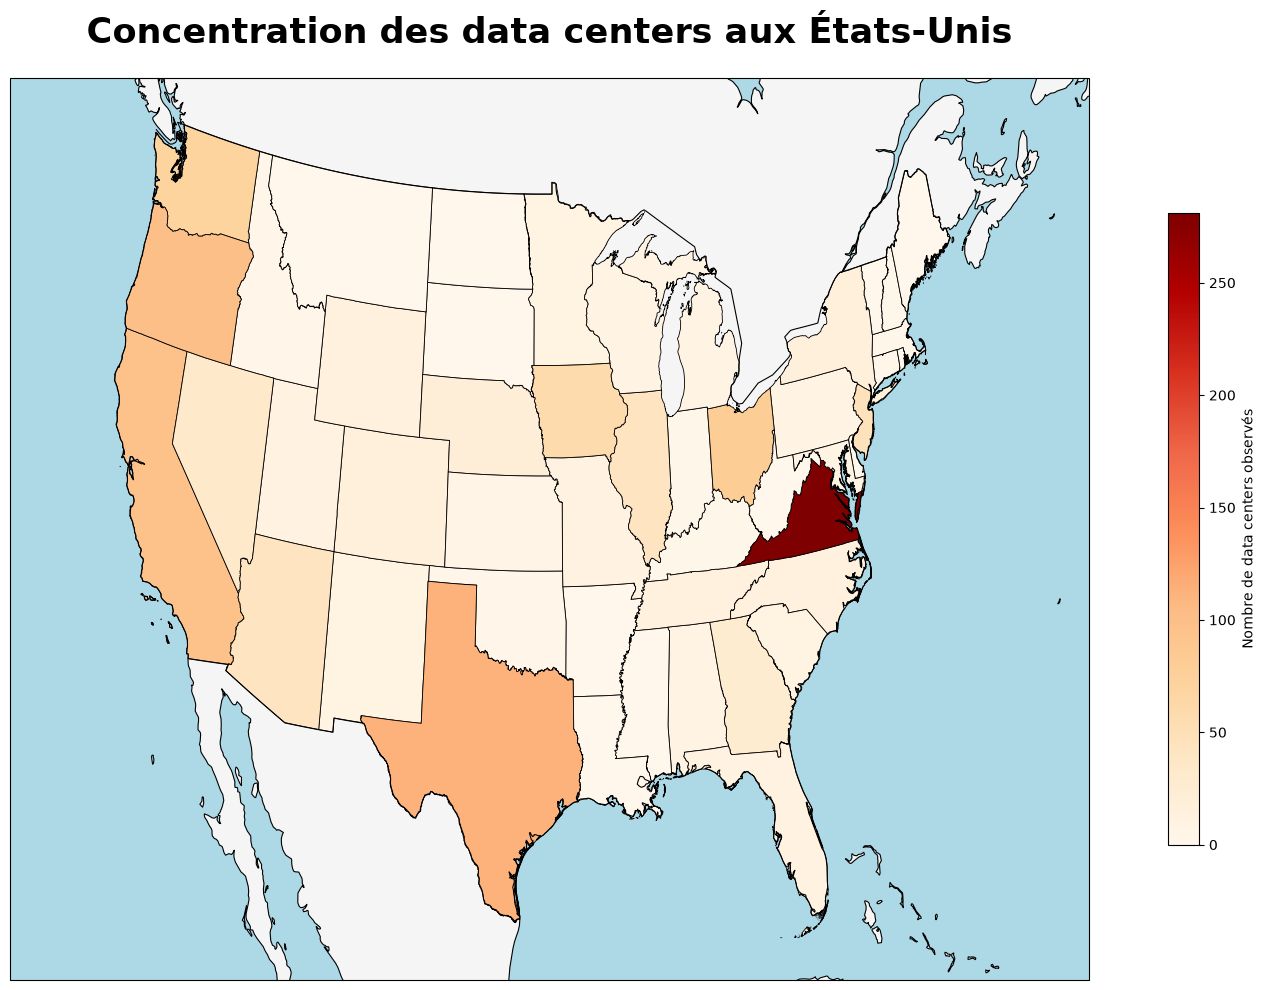

In [11]:
# ============================================================
# 5.4 CARTE CHOROPLÈTHE
# ============================================================

# Projection adaptée aux États-Unis
projection = ccrs.AlbersEqualArea(
    central_longitude=-96,
    central_latitude=37.5
)

fig = plt.figure(figsize=(16, 10))

ax = plt.axes(
    projection=projection
)


# ------------------------------------------------------------
# Emprise de la carte
# ------------------------------------------------------------

ax.set_extent(
    [-125, -66, 24, 50],
    crs=ccrs.PlateCarree()
)


# ------------------------------------------------------------
# Fond géographique Cartopy
# ------------------------------------------------------------

ax.add_feature(
    cfeature.LAND,
    facecolor="whitesmoke"
)

ax.add_feature(
    cfeature.OCEAN,
    facecolor="lightblue"
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.8
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.8
)


# ------------------------------------------------------------
# Choroplèthe GeoPandas
# ------------------------------------------------------------

states_map.plot(
    ax=ax,

    # Variable représentée
    column="data_centers",

    # Palette
    cmap="OrRd",

    # Frontières des États
    edgecolor="black",
    linewidth=0.6,

    # Légende
    legend=True,

    legend_kwds={
        "label": "Nombre de data centers observés",
        "orientation": "vertical",
        "shrink": 0.7
    },

    # Important :
    # les données du shapefile sont en longitude/latitude
    transform=ccrs.PlateCarree()
)


# ------------------------------------------------------------
# Titre
# ------------------------------------------------------------

ax.set_title(
    "Concentration des data centers aux États-Unis",
    fontsize=25,
    fontweight="bold",
    pad=25
)


plt.tight_layout()
plt.show()

### 5.5 Ajout des codes des États

In [ ]:
# ============================================================
# 5.5 Ajouter les codes des États et le nombre de data centers
# ============================================================

# Projection métrique adaptée aux États-Unis
# states_projected = states_map.to_crs("EPSG:5070")
states_projected = states_map.to_crs("EPSG:5070")

# Calcul des centroïdes
# centroid_points = states_projected.geometry.centroid
centroid_points = (
    states_projected
    .geometry
    .representative_point()
)

# Transformer les centroïdes en longitude / latitude
centroid_points = (
    gpd.GeoSeries(
        centroid_points,
        crs="EPSG:5070"
    )
    .to_crs("EPSG:4326")
)

# ------------------------------------------------------------
# Ajouter les labels sur la carte
# ------------------------------------------------------------

for i, row in states_map.iterrows():

    # Récupérer le centroïde correspondant
    point = centroid_points.loc[i]

    # Afficher uniquement les États ayant au moins
    # un data center dans notre dataset
    if row["data_centers"] > 0:

        ax.text(
            point.x,
            point.y,

            f"{row['STUSPS']}\n"
            f"{row['data_centers']}",

            transform=ccrs.PlateCarree(),

            fontsize=7,
            ha="center",
            va="center",
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

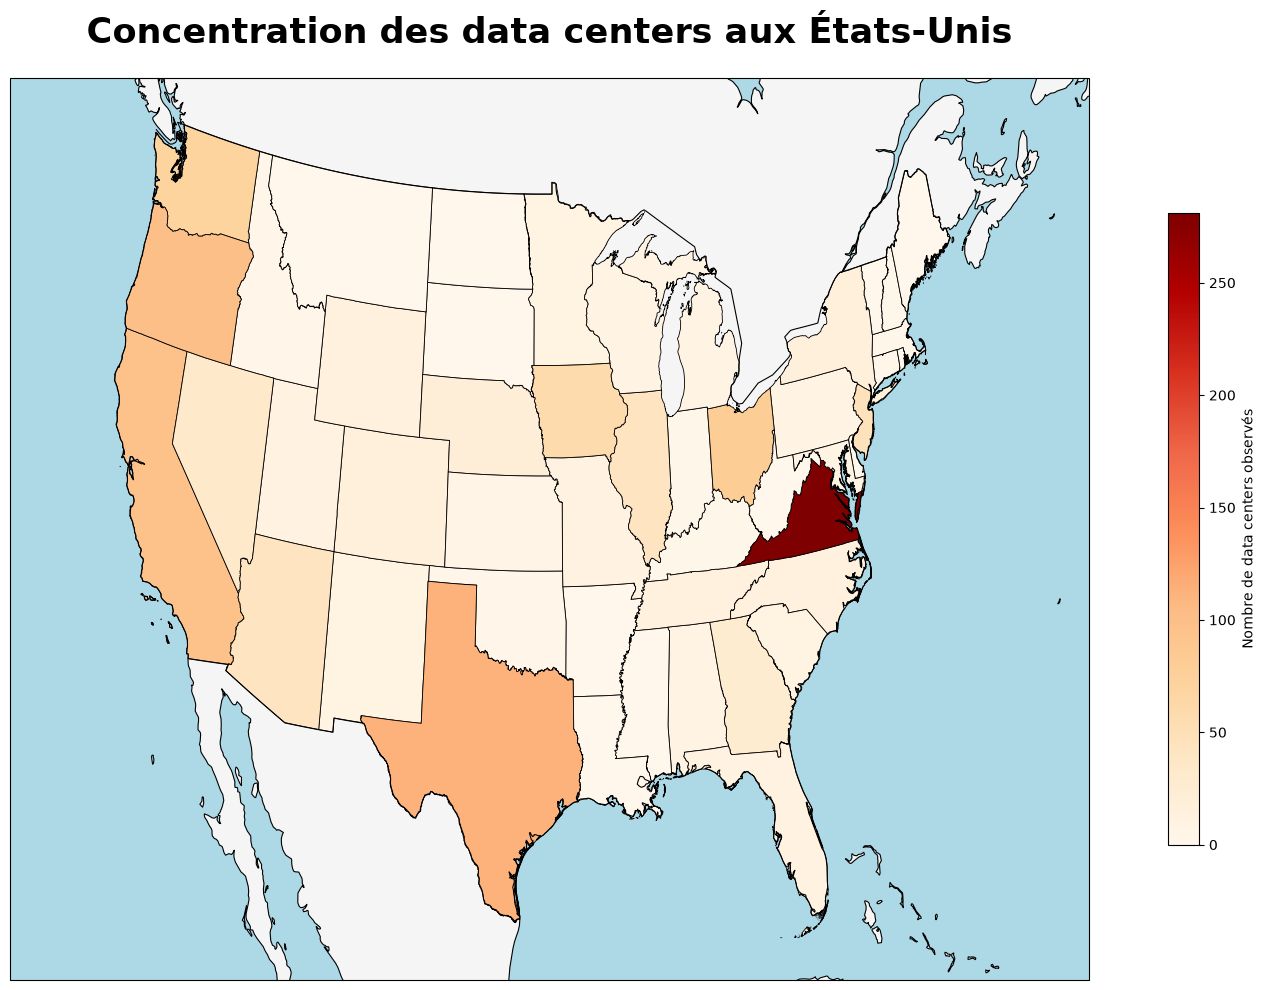

In [24]:
# Projection adaptée aux États-Unis
projection = ccrs.AlbersEqualArea(
    central_longitude=-96,
    central_latitude=37.5
)

fig = plt.figure(figsize=(16, 10))

ax = plt.axes(
    projection=projection
)


# ------------------------------------------------------------
# Emprise de la carte
# ------------------------------------------------------------

ax.set_extent(
    [-125, -66, 24, 50],
    crs=ccrs.PlateCarree()
)


# ------------------------------------------------------------
# Fond géographique Cartopy
# ------------------------------------------------------------

ax.add_feature(
    cfeature.LAND,
    facecolor="whitesmoke"
)

ax.add_feature(
    cfeature.OCEAN,
    facecolor="lightblue"
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.8
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.8
)


# ------------------------------------------------------------
# Choroplèthe GeoPandas
# ------------------------------------------------------------

states_map.plot(
    ax=ax,

    # Variable représentée
    column="data_centers",

    # Palette
    cmap="OrRd",

    # Frontières des États
    edgecolor="black",
    linewidth=0.6,

    # Légende
    legend=True,

    legend_kwds={
        "label": "Nombre de data centers observés",
        "orientation": "vertical",
        "shrink": 0.7
    },

    # Important :
    # les données du shapefile sont en longitude/latitude
    transform=ccrs.PlateCarree()
)


# ------------------------------------------------------------
# Titre
# ------------------------------------------------------------

ax.set_title(
    "Concentration des data centers aux États-Unis",
    fontsize=25,
    fontweight="bold",
    pad=25
)


plt.tight_layout()
plt.show()

## 6. Carte des points avec Contextily

`EPSG:3857` est utilisé pour les fonds cartographiques web.

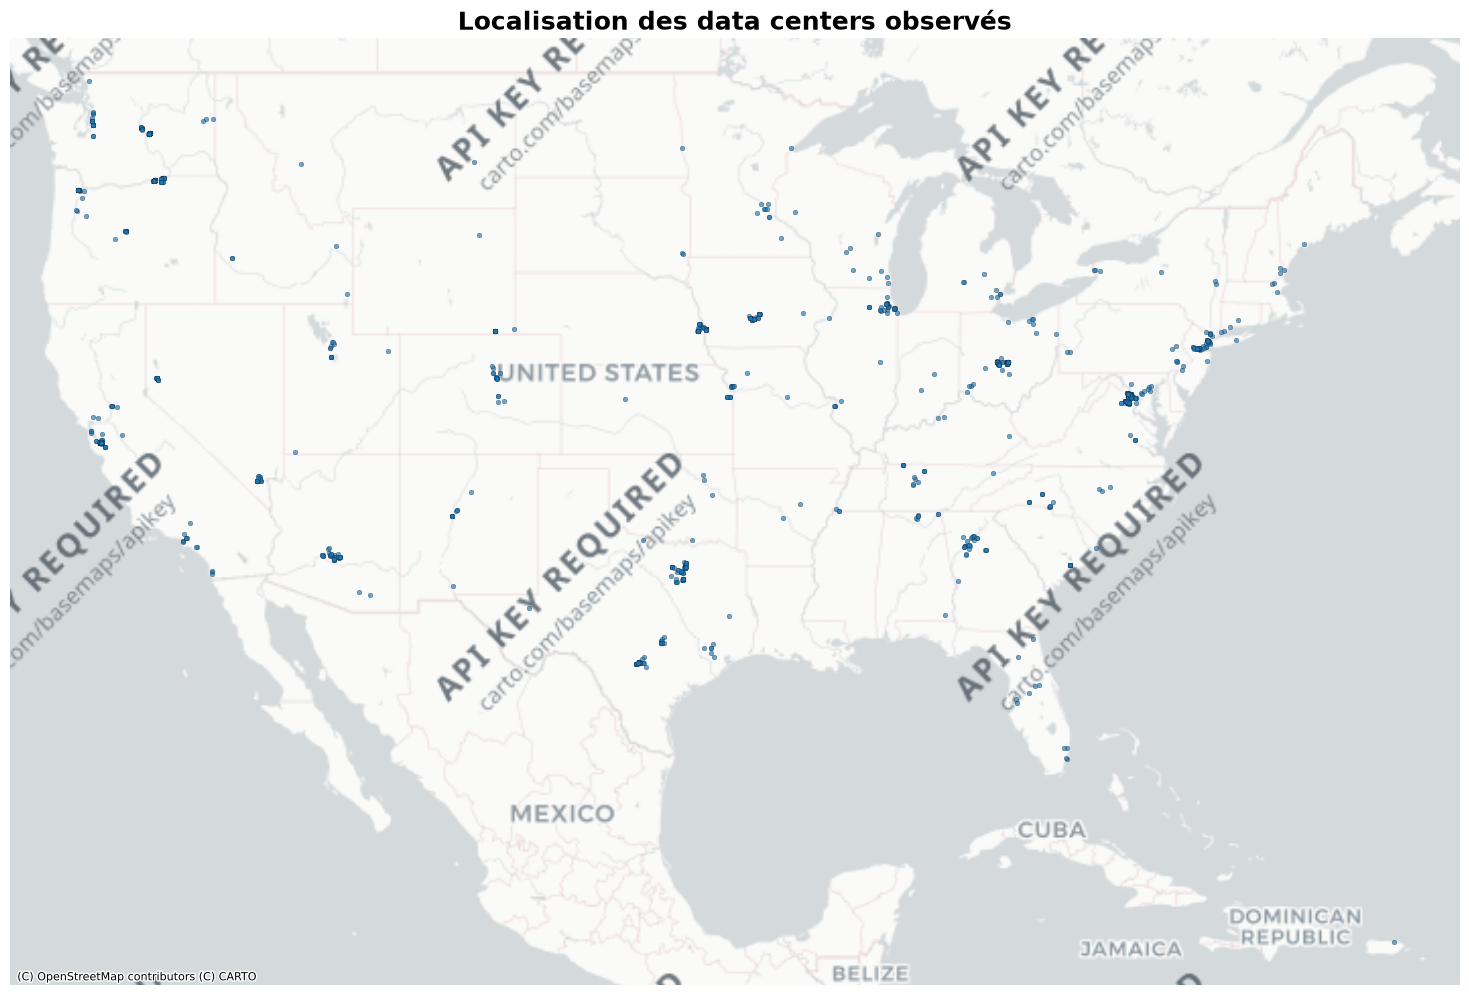

In [13]:
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(15, 10))
gdf_web.plot(ax=ax, markersize=12, alpha=0.65, edgecolor="black", linewidth=0.2)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_title("Localisation des data centers observés",
             fontsize=18, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Analyse des opérateurs

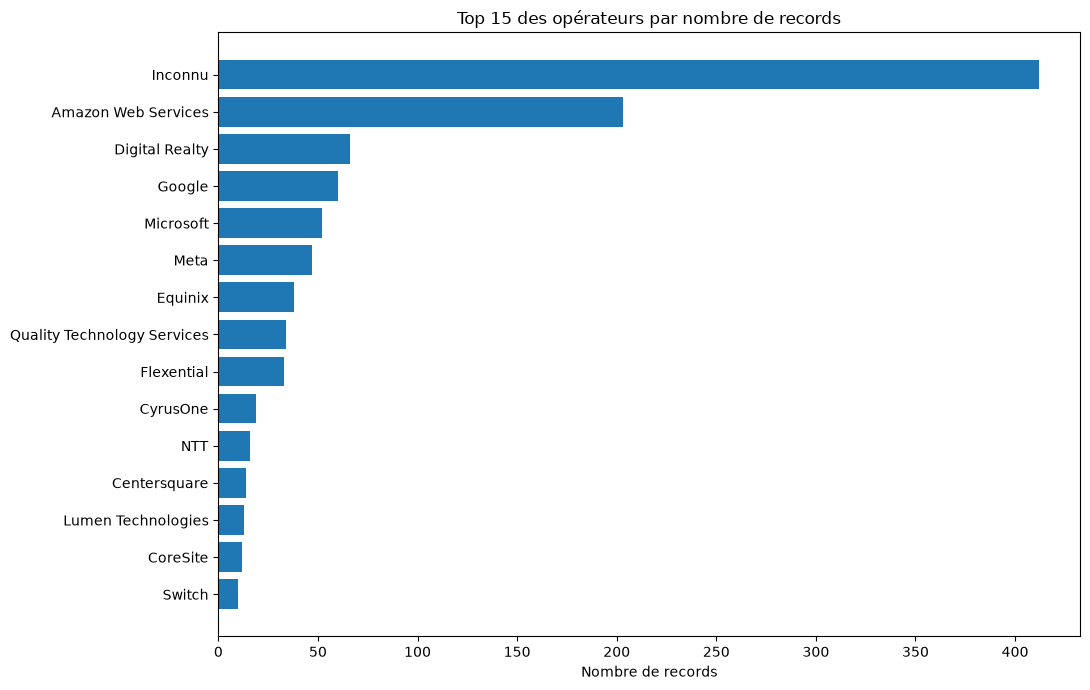

,count
operator,
Switch,10
CoreSite,12
Lumen Technologies,13
Centersquare,14
NTT,16
CyrusOne,19
Flexential,33
Quality Technology Services,34
Equinix,38


In [14]:
if "operator" in gdf.columns:
    operator_counts = (
        gdf["operator"].fillna("Inconnu").replace("", "Inconnu")
        .value_counts().head(15).sort_values()
    )
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(operator_counts.index, operator_counts.values)
    ax.set_title("Top 15 des opérateurs par nombre de records")
    ax.set_xlabel("Nombre de records")
    plt.tight_layout()
    plt.show()
    display(operator_counts.to_frame("count"))
else:
    print("Colonne operator absente.")

## 8. Carte interactive Plotly

In [26]:
hover_cols = [c for c in [
    "state", "county", "operator", "name", "latitude", "longitude"
] if c in gdf.columns]

fig = px.scatter_geo(
    gdf,
    lat="latitude",
    lon="longitude",
    scope="usa",
    projection="albers usa",
    hover_name="name" if "name" in gdf.columns else None,
    hover_data=hover_cols,
    title="Data centers américains — carte interactive"
)

fig.update_traces(marker=dict(size=6, opacity=0.65))
fig.update_layout(height=600, margin=dict(l=20, r=20, t=70, b=20))
fig.show()

## 9. KPI de synthèse et conclusions

Les conclusions sont générées à partir des données effectivement chargées.

In [28]:
total_records = len(gdf)
total_states = gdf["state"].nunique()
count_col = "data_centers" if "data_centers" in state_counts.columns else "data_center_count"

state_counts = state_counts.sort_values(
    count_col,
    ascending=False
).copy()

state_counts["share_pct"] = (
    state_counts[count_col]
    / state_counts[count_col].sum()
    * 100
)

top5_share = state_counts.head(5)["share_pct"].sum()

print(f"Records analysés : {total_records:,}")
print(f"États représentés : {total_states}")
print(f"Part des 5 premiers États : {top5_share:.1f}%")
print("\nTop 5 :")
display(state_counts.head(5))

print("\nConclusion :")
print(
    "La distribution des records est géographiquement concentrée. "
    "Le KPI de concentration permet de quantifier cette concentration "
    "au-delà de la simple lecture de la carte."
)
print(
    "Limite : l'Atlas est une source ouverte et sa couverture ne doit "
    "pas être interprétée comme un recensement exhaustif de tous les sites."
)

Records analysés : 1,237
États représentés : 44
Part des 5 premiers États : 54.3%

Top 5 :


,state_abb,data_centers,share_pct,cumulative_pct
40,VA,281,22.716249,92.320129
38,TX,113,9.135004,68.552951
32,OR,100,8.084074,56.507680
3,CA,97,7.841552,12.045271
30,OH,81,6.548100,48.100243



Conclusion :
La distribution des records est géographiquement concentrée. Le KPI de concentration permet de quantifier cette concentration au-delà de la simple lecture de la carte.
Limite : l'Atlas est une source ouverte et sa couverture ne doit pas être interprétée comme un recensement exhaustif de tous les sites.


# 🚀 Extensions portfolio

- ajouter capacité énergétique (MW/GW) ;
- distinguer opérationnel / construction / projet ;
- analyser l'évolution temporelle ;
- comparer opérateurs et États ;
- ajouter prix de l'électricité et capacité du réseau ;
- intégrer données fibre/réseaux ;
- calculer densité de sites par km² ;
- tester du clustering spatial (`DBSCAN`) ;
- construire un dashboard Streamlit ou Power BI.

### Question métier avancée

> **Quels territoires américains présentent les caractéristiques infrastructurelles les plus favorables au développement de nouveaux data centers ?**

Cette extension nécessiterait plusieurs sources complémentaires et une méthodologie de scoring explicitement documentée.